Labelversion 3, Testsize 20%, inkl. Energy_Crop + energy shift (more energy shift)

In [1]:
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset
import pandas as pd
import torchvision.models as tv_models
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from torchvision.ops import sigmoid_focal_loss

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
class ARPESDataset(Dataset):

    def __init__(self, h5_path, labels=None, indices=None, transform=None):

        self.h5_path = h5_path
        self.labels = np.array(labels) if labels is not None else None

        with h5py.File(h5_path, "r", libver="latest", swmr=True) as f:
                data = f["entry/acquisition/data"]
                x = np.arange(data.shape[2])     

        self.indices = np.array(indices) if indices is not None else (
            np.arange(len(self.labels)) if self.labels is not None else None
        )

        if self.indices is None:
            with h5py.File(h5_path, "r", libver="latest", swmr=True) as f:
                data = f["entry/acquisition/data"]
                self.indices = np.arange(data.shape[2])   
                
        self.transform = transform

        self._file = None
        self._data = None

    def _init_file(self):
        if self._file is None:
            self._file = h5py.File(self.h5_path, "r", libver="latest", swmr=True)
            self._data = self._file["entry/acquisition/data"]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):

        self._init_file()

        idx = self.indices[i]
        img = self._data[:, :, idx]

        if self.transform:
            img = self.transform(img)

        if not torch.is_tensor(img):
            img = torch.tensor(img, dtype=torch.float32)

        if img.ndim == 2:
            img = img.unsqueeze(0)
        elif img.ndim == 3 and img.shape[0] != 1:
            # already channel-first tensor
            pass

        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return img, label

In [4]:
class ARPEStestDataset(Dataset):

    def __init__(self, h5_path, labels=None, indices=None, transform=None):

        self.h5_path = h5_path
        self.labels = np.array(labels) if labels is not None else None

        with h5py.File(h5_path, "r", libver="latest", swmr=True) as f:
                data = f["entry/acquisition/data"]
                x = np.arange(data.shape[2])     

        self.indices = np.array(indices) if indices is not None else (
            np.arange(len(self.labels)) if self.labels is not None else None
        )

        if self.indices is None:
            with h5py.File(h5_path, "r", libver="latest", swmr=True) as f:
                data = f["entry/acquisition/data"]
                self.indices = np.arange(data.shape[2])   
                
        self.transform = transform

        self._file = None
        self._data = None

    def _init_file(self):
        if self._file is None:
            self._file = h5py.File(self.h5_path, "r", libver="latest", swmr=True)
            self._data = self._file["entry/acquisition/data"]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):

        self._init_file()

        idx = self.indices[i]
        img = self._data[:, :, idx]

        if self.transform:
            img = self.transform(img)

        if not torch.is_tensor(img):
            img = torch.tensor(img, dtype=torch.float32)

        if img.ndim == 2:
            img = img.unsqueeze(0)
        elif img.ndim == 3 and img.shape[0] != 1:
            # already channel-first tensor
            pass

        return img

In [5]:
class LogNormalize:
    def __call__(self, img):
        img = np.log1p(img.astype(np.float32))
        img = img - img.min()
        img = img / (img.max() + 1e-8)
        return img

In [6]:
import numpy as np
import random

class RandomEnergyWindowCrop:

    def __init__(self, e_min, e_max, window_width_eV):

        self.e_min = e_min
        self.e_max = e_max
        self.window_width_eV = window_width_eV

    def __call__(self, img):

        H, W = img.shape
        #print(f"Original image shape: {img.shape}")
        e_axis = np.linspace(self.e_min, self.e_max, H)

        center = random.uniform(
            self.e_min + self.window_width_eV/2,
            self.e_max - self.window_width_eV/2
        )

        half = self.window_width_eV / 2

        left = np.searchsorted(e_axis, center - half)
        right = np.searchsorted(e_axis, center + half)

        # print(
        #     f"E-range: "
        #     f"{e_axis[left]:.3f} eV -> "
        #     f"{e_axis[right-1]:.3f} eV"
        # )


        return img[left:right,:]

In [7]:
# crop spectra to defined energy window
class EnergyWindowCrop:

    def __init__(self, e_min, e_max):
        self.e_min = e_min
        self.e_max = e_max

    def __call__(self, img):
        H, W = img.shape
        #print(f"Original image shape: {img.shape}")
        e_axis = np.linspace(self.e_min, self.e_max, H)

        window_width_eV = self.e_max - self.e_min
        center = 6.45

        half = window_width_eV / 2

        left = np.searchsorted(e_axis, center - half)
        right = np.searchsorted(e_axis, center + half)

        # print(
        #     f"E-range: "
        #     f"{e_axis[left]:.3f} eV -> "
        #     f"{e_axis[right-1]:.3f} eV"
        # )

        return img[left:right,:]


    

In [8]:
class EnergyShift:
    """
    Simuliert eine kleine Energieverschiebung (Drift im Analyzer/Kalibrierung).

    Parameters
    ----------
    max_shift : int, optional
        Maximale Verschiebung in Pixeln entlang der Energieachse.
    p : float, optional
        Wahrscheinlichkeit, mit der die Verschiebung angewendet wird.
    """

    def __init__(self, max_shift=3, p=0.5):
        self.max_shift = max_shift
        self.p = p

    def __call__(self, x):
        # Augmentation nur mit Wahrscheinlichkeit p anwenden
        if np.random.rand() > self.p:
            return x

        shift = np.random.randint(-self.max_shift, self.max_shift + 1)

        # Falls zufällig keine Verschiebung gewählt wurde
        if shift == 0:
            return x

        # Verschiebung entlang der Energieachse (axis=0)
        return np.roll(x, shift, axis=0)

    def __repr__(self):
        return (f"{self.__class__.__name__}"
                f"(max_shift={self.max_shift}, p={self.p})")

In [9]:
class AngleShift:
    """
    Simuliert eine kleine k-Raum-Verschiebung (Angle/Momentum shift).

    Parameters
    ----------
    max_shift : int
        Maximale Verschiebung in Pixeln entlang der Winkelachse (axis=1).
    p : float
        Wahrscheinlichkeit, mit der die Verschiebung angewendet wird.
    """

    def __init__(self, max_shift=2, p=0.5):
        self.max_shift = max_shift
        self.p = p

    def __call__(self, x):
        # Wahrscheinlichkeit prüfen
        if np.random.rand() > self.p:
            return x

        shift = np.random.randint(-self.max_shift, self.max_shift + 1)

        # keine Verschiebung
        if shift == 0:
            return x

        # Verschiebung entlang Winkelachse (axis=1)
        return np.roll(x, shift, axis=1)

    def __repr__(self):
        return f"{self.__class__.__name__}(max_shift={self.max_shift}, p={self.p})"

In [10]:
from torchvision import transforms

transform = transforms.Compose([
    EnergyShift(max_shift=15, p=0.5),
    AngleShift(max_shift=10, p=0.5),
    RandomEnergyWindowCrop(5.0, 6.8, window_width_eV=1.3),
    LogNormalize(),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize((288, 216))
])

transform_for_raw = transforms.Compose([
    EnergyWindowCrop(5.3, 6.6),
    LogNormalize(),
    transforms.ToTensor(),
    transforms.Resize((288, 216))
])

In [11]:
#labels_df = pd.read_csv('/Users/katharinasteinkirchner/Documents/Machine Learning/Classification_table.csv', delimiter=';', usecols=['Symmetrie', 'Resolution'])
labels_df_2 = pd.read_excel('/Users/katharinasteinkirchner/Documents/Machine Learning/Classification_table_Version3.xlsx', usecols=['Resolution'])
#labels_df_2 = pd.read_excel('/Users/atimm/Documents/ML/data/Classification_table_Version2.xlsx', usecols=['Resolution'])

#y = labels_df['Symmetrie'] * labels_df['Resolution']
y = labels_df_2['Resolution']

h5_path = '/Users/katharinasteinkirchner/Documents/Machine Learning/x_y_grid_20260417_105734_020_z000000_snapshot_20260504_103145.h5'
#h5_path = '/users/atimm/Documents/ML/data/x_y_grid_20260417_105734_020_z000000_snapshot_20260504_103145.h5'
with h5py.File(h5_path, "r", libver="latest", swmr=True) as f:
    data = f["entry/acquisition/data"]
    num_samples = data.shape[2]
    print(data.chunks)

(288, 216, 67)


In [12]:
from sklearn.model_selection import train_test_split
import numpy as np
from collections import Counter

indices = np.arange(len(y))

def safe_stratify(labels):
    counts = Counter(labels)
    if len(counts) == 0:
        return None
    return labels if min(counts.values()) >= 2 else None

# train_stratify = safe_stratify(y)
# train_idx, test_idx = train_test_split(
#     indices,
#     test_size=0.15, 
#     random_state=42,
#     stratify=train_stratify
# )

# val_stratify = safe_stratify(y[train_idx])
# train_idx, val_idx = train_test_split(
#     train_idx,
#     test_size=0.1765,
#     random_state=42,
#     stratify=val_stratify
# )


# variante ohne test set, nur train/val split
train_stratify = safe_stratify(y)
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2, 
    random_state=42,
    stratify=train_stratify
)

In [13]:
train_dataset = ARPESDataset(h5_path, y, train_idx, transform)
val_dataset   = ARPESDataset(h5_path, y, val_idx, transform)
#test_dataset  = ARPESDataset(h5_path, y, test_idx, transform)

full_dataset = ARPESDataset(h5_path, y, transform=transform_for_raw)
full_loader = DataLoader(full_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)

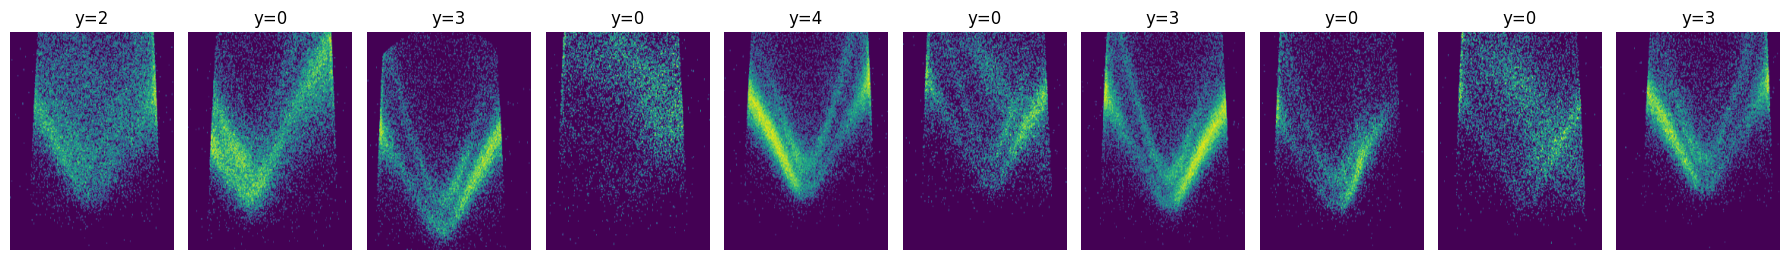

In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

# test_loader = DataLoader(
#     test_dataset,
#     batch_size=32,
#     shuffle=False,
#     num_workers=0
# )

fig, ax = plt.subplots(1, 10, figsize=(18, 3))
for i in range(10):
     img, label = train_dataset[i]
     ax[i].set_title(f"y={label.item()}")
     ax[i].axis("off")
     ax[i].imshow(img.squeeze(0))
plt.tight_layout()
plt.show()

In [15]:
import os
import certifi
from torchvision.models import resnet50, ResNet50_Weights

os.environ["SSL_CERT_FILE"] = certifi.where()

weights = ResNet50_Weights.IMAGENET1K_V1
model = resnet50(weights=weights)

In [16]:
import torch.nn as nn
import torchvision.models as tv_models
import numpy as np

# Load pretrained ResNet-50
model = tv_models.resnet50(pretrained=True)

# Modify first conv layer for grayscale input (1 channel)
model.conv1 = nn.Conv2d(
    1, 64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

# Number of features in final layer
num_ftrs = model.fc.in_features  # 2048 for ResNet-50

# Replace classification head
model.fc = nn.Sequential(
    nn.Dropout(p=0.7),
    nn.Linear(num_ftrs, len(np.unique(y)))
)

# Freeze all parameters
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last 2 residual blocks + classifier
for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True


# Move to device
model = model.to(device)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [17]:
class_counts = np.bincount(y)

weights = len(y) / (len(class_counts) * class_counts)

print(weights)

[0.80593607 2.10119048 1.63425926 0.55678233 1.14239482]


In [18]:
# Optimizer: only params with requires_grad=True
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5, weight_decay=1e-4)
#criterion = nn.CrossEntropyLoss()
#criterion = sigmoid_focal_loss
# LR scheduler (reduce LR on plateau of validation loss)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

boost_factors = {
    3: 1,
    4: 1,
}

weights = torch.tensor(
    weights,
    dtype=torch.float32,
    device=device
)

for cls, factor in boost_factors.items():
    weights[cls] *= factor

print(weights)

criterion = nn.CrossEntropyLoss(
    weight=weights,label_smoothing=0.05
)

tensor([0.8059, 2.1012, 1.6343, 0.5568, 1.1424], device='mps:0')


In [19]:
import matplotlib.pyplot as plt
import numpy as np


def plot_training_metrics(
    train_acc_history,
    val_acc_history,
    precision4_history,
    recall4_history,
    save_path=None,
    txt_path=None
):
    """
    Plot Accuracy, Precision4 und Recall4 über die Epochen.
    Optional können die Werte in einer Textdatei gespeichert werden.
    """

    # Safety check for empty histories
    if not val_acc_history or not precision4_history:
        print("Warning: Training metrics are empty. Did training complete?")
        return

    epochs = np.arange(1, len(val_acc_history) + 1)

    # -----------------------------
    # Werte als Textdatei speichern
    # -----------------------------
    if txt_path is not None:
        with open(txt_path, "w") as f:
            f.write("Epoch\tTrainAccuracy\tValidationAccuracy\tPrecision4\tRecall4\n")
            for e, train_acc, val_acc, prec, rec in zip(
                epochs,
                train_acc_history,
                val_acc_history,
                precision4_history,
                recall4_history,
            ):
                f.write(
                    f"{e}\t{train_acc:.6f}\t{val_acc:.6f}\t{prec:.6f}\t{rec:.6f}\n"
                )

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy
    ax[0].plot(
        epochs,
        train_acc_history,
        marker='o',
        linewidth=2,
        label='Train Accuracy'
    )

    ax[0].plot(
        epochs,
        val_acc_history,
        marker='s',
        linewidth=2,
        label='Validation Accuracy'
    )

    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Accuracy')
    ax[0].set_title('Accuracy')
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    # Precision / Recall Klasse 4
    ax[1].plot(
        epochs,
        precision4_history,
        marker='o',
        linewidth=2,
        label='Precision (Class 4)'
    )

    ax[1].plot(
        epochs,
        recall4_history,
        marker='s',
        linewidth=2,
        label='Recall (Class 4)'
    )

    best_epoch = np.argmax(precision4_history) + 1

    ax[1].axvline(
        best_epoch,
        color='red',
        linestyle='--',
        alpha=0.7,
        label=f'Best Precision4 (Epoch {best_epoch})'
    )

    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Score')
    ax[1].set_title('Class 4 Metrics')
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

Train samples: 1412, Val samples: 353
Batches per epoch (train): 45, (val): 12

Epoch 1/60


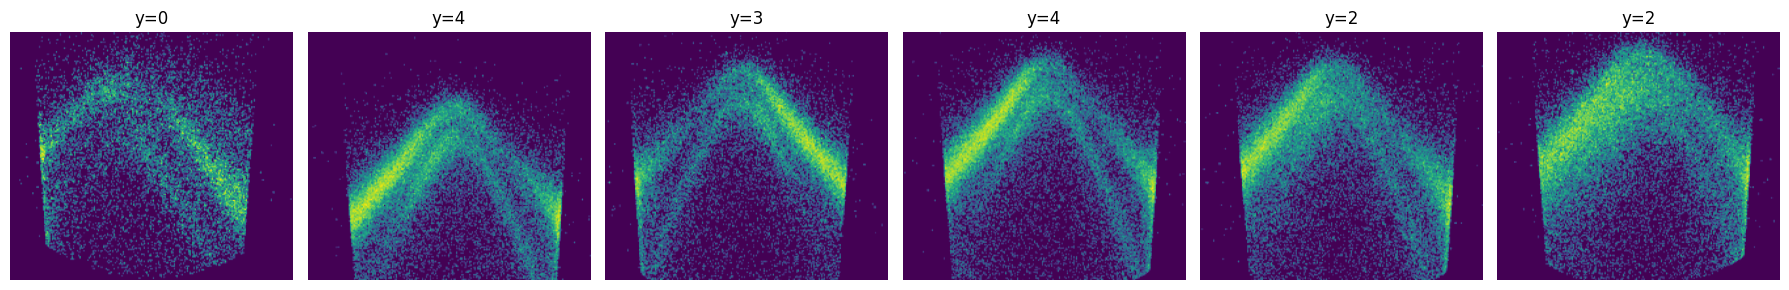

train Loss=1.5411 Acc=0.3159 Precision4=0.2550 Recall4=0.2065 SchedulerLR=1.00e-05


val Loss=1.5989 Acc=0.3484 Precision4=0.1892 Recall4=0.1129 SchedulerLR=1.00e-05

Epoch 2/60


train Loss=1.2563 Acc=0.4504 Precision4=0.3420 Recall4=0.4777 SchedulerLR=1.00e-05


val Loss=1.1075 Acc=0.5524 Precision4=0.4385 Recall4=0.9194 SchedulerLR=1.00e-05

Epoch 3/60


train Loss=1.0897 Acc=0.5425 Precision4=0.4275 Recall4=0.7166 SchedulerLR=1.00e-05


...

val Loss=0.5572 Acc=0.8357 Precision4=0.7176 Recall4=0.9839 SchedulerLR=3.91e-08

Epoch 59/60


train Loss=0.5712 Acc=0.8541 Precision4=0.7440 Recall4=0.8826 SchedulerLR=3.91e-08


val Loss=0.5700 Acc=0.8612 Precision4=0.7595 Recall4=0.9677 SchedulerLR=3.91e-08

Epoch 60/60


train Loss=0.5873 Acc=0.8513 Precision4=0.7390 Recall4=0.8826 SchedulerLR=3.91e-08


val Loss=0.5484 Acc=0.8499 Precision4=0.6897 Recall4=0.9677 SchedulerLR=3.91e-08


In [20]:
# training version - plus precision/recall for class 4 and scheduler

# Debug: Show dataset sizes
#print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
#print(f"Batches per epoch (train): {len(train_loader)}, (val): {len(val_loader)}")

print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}")
print(f"Batches per epoch (train): {len(train_loader)}, (val): {len(val_loader)}")

train_acc_history = []
val_acc_history = []

precision4_history = []
recall4_history = []

epochs_history = []

num_epochs = 60
best_precision4 = 0
visualize_once = True

for epoch in range(num_epochs):

    full_pred = []

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    epoch_start = time.time()
    
    for phase in ['train', 'val']:

        tp4 = 0
        fp4 = 0
        fn4 = 0

        all_preds = []
        all_labels = []
        
        if phase == 'train':

            model.train()
            dataloader = train_loader

            # Visualize only in first epoch, 
            if visualize_once and epoch == 0:

                for x, z in dataloader:

                    fig, axes = plt.subplots(1, 6, figsize=(18, 3))

                    for i in range(6):

                        img = x[i, 0].cpu().numpy()
                        label = z[i].cpu().numpy()
                        axes[i].imshow(img, aspect='auto', origin='lower', cmap='viridis')
                        axes[i].set_title(f"y={label.item()}")
                        axes[i].axis("off")

                    plt.tight_layout()
                    plt.show()

                    break

                visualize_once = False         

        else:

            model.eval()
            dataloader = val_loader

        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in tqdm(dataloader, desc=f"{phase} epoch {epoch+1}", leave=False):

            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # harte Vorhersage (argmax)

                _, preds = torch.max(outputs, 1)
                pred_is4 = preds == 4
                label_is4 = labels == 4
                full_pred.extend(preds.cpu().numpy())

                # tp4 += (pred_is4 & label_is4).sum().item()
                # fp4 += (pred_is4 & ~label_is4).sum().item()
                # fn4 += (~pred_is4 & label_is4).sum().item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        if phase == 'val':
            scheduler.step(epoch_acc)
        precision4 = precision_score(
            all_labels,
            all_preds,
            labels=[4],
            average='macro',
            zero_division=0
        )
        recall4 = recall_score(
            all_labels,
            all_preds,
            labels=[4],
            average='macro',
            zero_division=0
        )

        if phase == 'val' and precision4 > best_precision4:
            best_precision4 = precision4

            torch.save({
                "model_state_dict": model.state_dict(),
                "class_names": np.unique(y).tolist(),
                "transform": "LogNormalize + RandomEnergyWindowCrop",
            }, "arpes_resnet50_best.pt")

        print(
            f"{phase} "
            f"Loss={epoch_loss:.4f} "
            f"Acc={epoch_acc:.4f} "
            f"Precision4={precision4:.4f} "
            f"Recall4={recall4:.4f} "
            f"SchedulerLR={scheduler._last_lr[0]:.2e}"
        )

        # Append metrics to history
        if phase == 'train':
            train_acc_history.append(epoch_acc)
        else:
            val_acc_history.append(epoch_acc)
            precision4_history.append(precision4)
            recall4_history.append(recall4)

        # df = pd.DataFrame({'y_pred': full_pred})
        # df.to_csv('y_preds.csv', index=False)


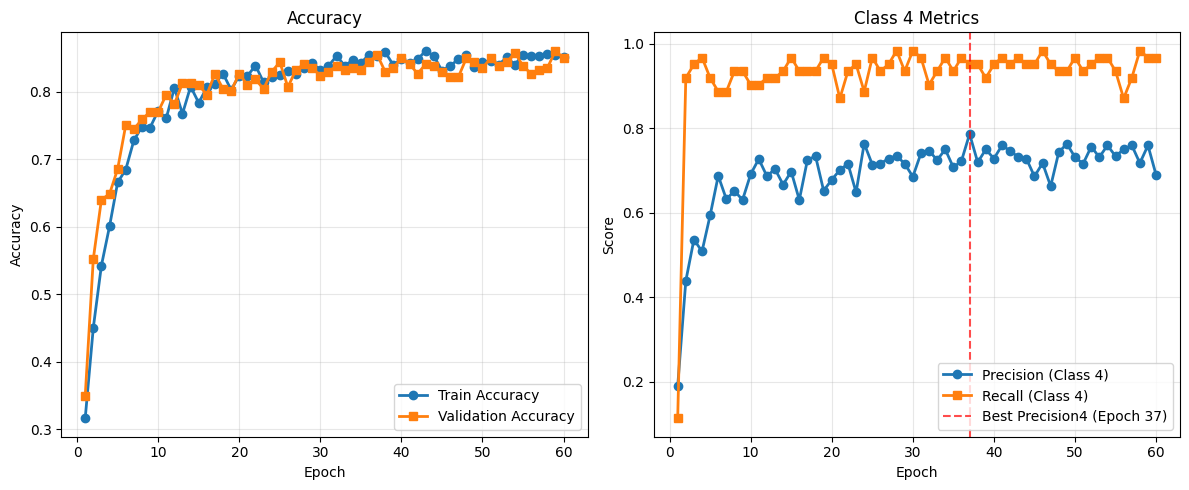

In [21]:
plot_training_metrics(
    train_acc_history,
    val_acc_history,
    precision4_history,
    recall4_history,
    #save_path="training_metrics.png",
    txt_path="training_metrics_resnet_50_best.txt"
)

Predicted class distribution:
0 406
1 250
2 205
3 463
4 441
2
Total samples: 1765, Padded samples: 1767


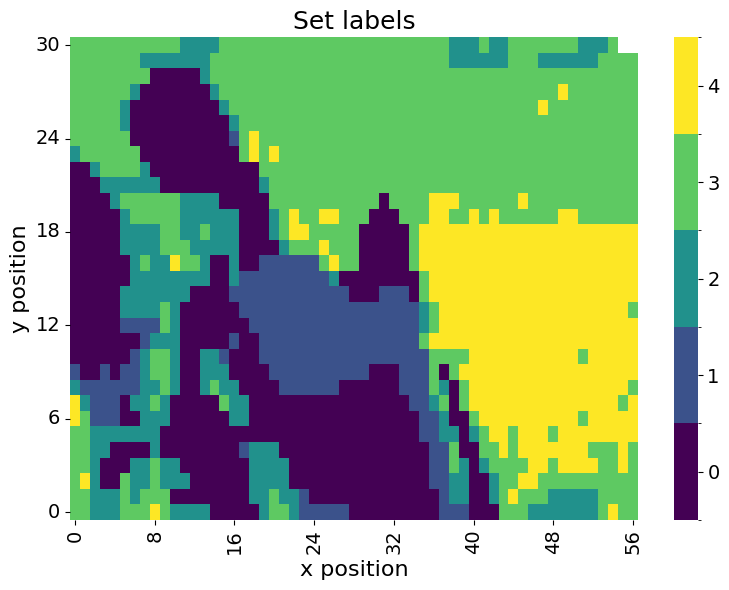

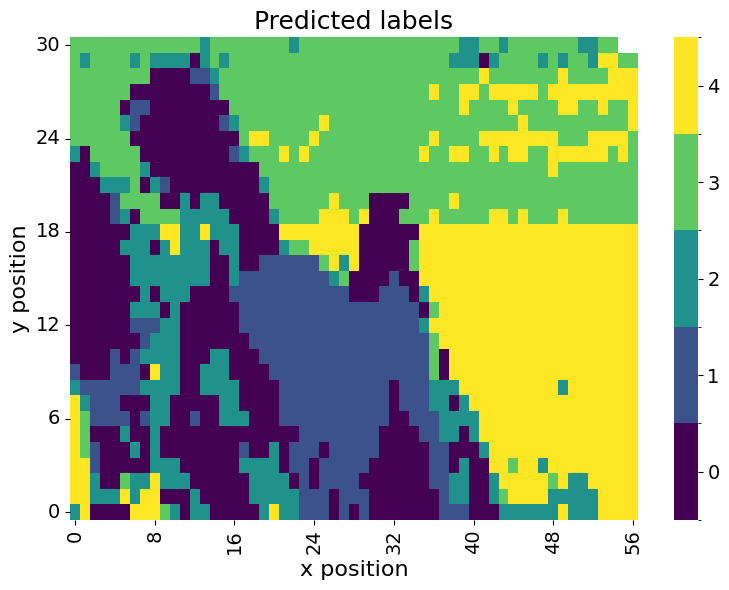

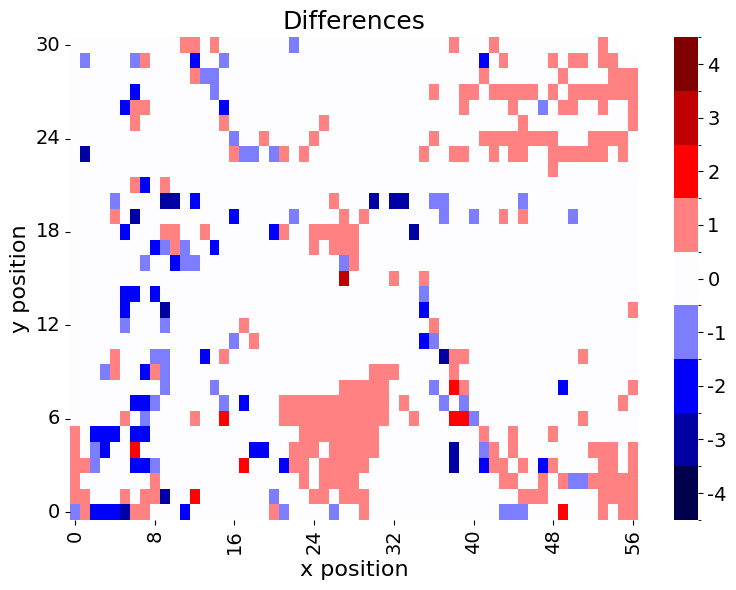

In [22]:
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

x = 57  # number of measurements (ARPES spectra) in x direction on sample

# --------------------------------------------------
# Predictions of model for all samples in dataset
# --------------------------------------------------
y_pred_full = []

model.eval()
with torch.no_grad():
    for inputs, _ in full_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_pred_full.extend(preds.cpu().numpy())

# Debug: Show predicted class distribution
unique, counts = np.unique(y_pred_full, return_counts=True)
print("Predicted class distribution:")
for u, c in zip(unique, counts):
    print(u, c)

# --------------------------------------------------
# Convert predictions to matrix
# --------------------------------------------------
arr = np.asarray(y_pred_full, dtype=float)
pad_len = (-len(arr)) % x

print(pad_len)
print(f"Total samples: {len(arr)}, Padded samples: {len(arr) + pad_len}")

arr_padded = np.pad(arr, (0, pad_len), constant_values=np.nan)
pred_matrix = arr_padded.reshape(-1, x)

# --------------------------------------------------
# Convert ground truth to matrix
# --------------------------------------------------
true_array = np.asarray(
    y.cpu() if isinstance(y, torch.Tensor) else y,
    dtype=float
)

pad_len_true = (-len(true_array)) % x
true_array_padded = np.pad(
    true_array,
    (0, pad_len_true),
    constant_values=np.nan
)

true_matrix = true_array_padded.reshape(-1, x)

# --------------------------------------------------
# Difference matrix
# --------------------------------------------------
diff_matrix = pred_matrix - true_matrix

# --------------------------------------------------
# Tick positions
# --------------------------------------------------
n_xticks = 8
n_yticks = 6

xticks = np.linspace(0, pred_matrix.shape[1]-1, n_xticks, dtype=int)
yticks = np.linspace(0, pred_matrix.shape[0]-1, n_yticks, dtype=int)

# --------------------------------------------------
# Discrete colormap for classes 0-4
# --------------------------------------------------
colors = [
    "#440154",  # 0
    "#3b528b",  # 1
    "#21918c",  # 2
    "#5ec962",  # 3
    "#fde725"   # 4
]

class_cmap = ListedColormap(colors)
class_norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), class_cmap.N)

# Discrete normalization for differences (-4 ... 4)
diff_norm = BoundaryNorm(np.arange(-4.5, 5.5, 1), 256)

# ==================================================
# Ground Truth
# ==================================================
fig, ax = plt.subplots(figsize=(8, 6))

heatmap = sns.heatmap(
    true_matrix,
    cmap=class_cmap,
    norm=class_norm,
    cbar=True,
    ax=ax
)

ax.invert_yaxis()

ax.set_xticks(xticks + 0.5)
ax.set_xticklabels(xticks)

ax.set_yticks(yticks + 0.5)
ax.set_yticklabels(yticks)

ax.set_xlabel("x position", fontsize=16)
ax.set_ylabel("y position", fontsize=16)
ax.set_title("Set labels", fontsize=18)
ax.tick_params(axis="both", labelsize=14)

cbar = heatmap.collections[0].colorbar
cbar.set_ticks([0, 1, 2, 3, 4])
cbar.set_ticklabels(["0", "1", "2", "3", "4"])
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()

# ==================================================
# Predictions
# ==================================================
fig, ax = plt.subplots(figsize=(8, 6))

heatmap = sns.heatmap(
    pred_matrix,
    cmap=class_cmap,
    norm=class_norm,
    cbar=True,
    ax=ax
)

ax.invert_yaxis()

ax.set_xticks(xticks + 0.5)
ax.set_xticklabels(xticks)

ax.set_yticks(yticks + 0.5)
ax.set_yticklabels(yticks)

ax.set_xlabel("x position", fontsize=16)
ax.set_ylabel("y position", fontsize=16)
ax.set_title("Predicted labels", fontsize=18)
ax.tick_params(axis="both", labelsize=14)

cbar = heatmap.collections[0].colorbar
cbar.set_ticks([0, 1, 2, 3, 4])
cbar.set_ticklabels(["0", "1", "2", "3", "4"])
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()

# ==================================================
# Differences
# ==================================================
fig, ax = plt.subplots(figsize=(8, 6))

heatmap = sns.heatmap(
    diff_matrix,
    cmap="seismic",
    norm=diff_norm,
    cbar=True,
    ax=ax
)

ax.invert_yaxis()

ax.set_xticks(xticks + 0.5)
ax.set_xticklabels(xticks)

ax.set_yticks(yticks + 0.5)
ax.set_yticklabels(yticks)

ax.set_xlabel("x position", fontsize=16)
ax.set_ylabel("y position", fontsize=16)
ax.set_title("Differences", fontsize=18)
ax.tick_params(axis="both", labelsize=14)

cbar = heatmap.collections[0].colorbar
cbar.set_ticks(np.arange(-4, 5))
cbar.set_ticklabels([str(i) for i in range(-4, 5)])
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()

(288, 216, 67)
Predicted class distribution:
0 358
1 2
2 149
4 787
0
Total samples: 1296, Padded samples: 1296


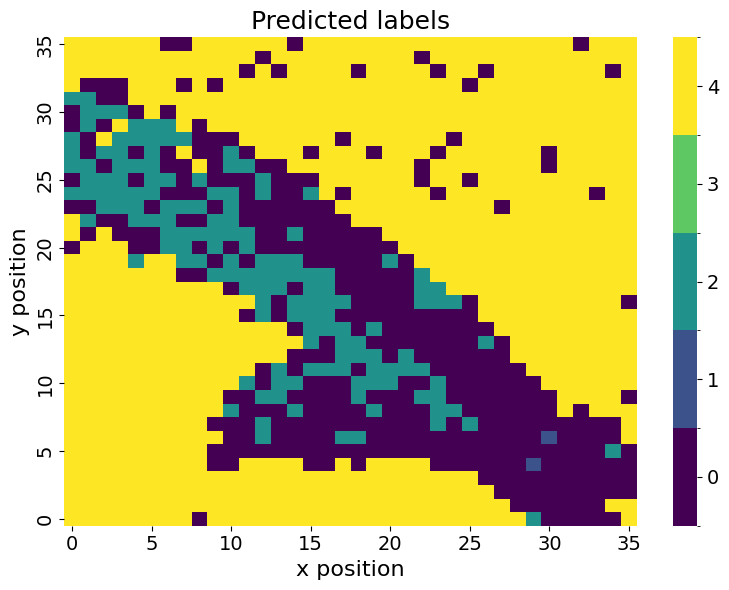

In [23]:
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

#h5_path_2 = "/Users/atimm/Documents/ML/data/Pos_map_20260526_161920_020_z000000_snapshot_20260526_174221_snapshot_20260616_135309.h5"
#h5_path_2 = "/Users/atimm/Documents/ML/data/Pos_map_20260526_161920_020_z000000_snapshot_20260526_174221_snapshot_20260616_135747.h5"
h5_path_2 = "/Users/katharinasteinkirchner/Documents/Machine Learning/Pos_map_20260526_161920_020_z000000_snapshot_20260526_174221_snapshot_20260616_135747.h5"

with h5py.File(h5_path_2, "r", libver="latest", swmr=True) as f:
    data = f["entry/acquisition/data"]
    num_samples = data.shape[2]
    print(data.chunks)

full_dataset_2 = ARPEStestDataset(h5_path_2, transform=transform_for_raw)
full_loader_2 = DataLoader(
    full_dataset_2,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

x = 36  # number of measurements (ARPES spectra) in x direction on sample

# --------------------------------------------------
# Predictions
# --------------------------------------------------
y_pred_full = []

model.eval()
with torch.no_grad():
    for inputs in full_loader_2:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_pred_full.extend(preds.cpu().numpy())

unique, counts = np.unique(y_pred_full, return_counts=True)

print("Predicted class distribution:")
for u, c in zip(unique, counts):
    print(u, c)

arr = np.asarray(y_pred_full, dtype=float)
pad_len = (-len(arr)) % x

print(pad_len)
print(f"Total samples: {len(arr)}, Padded samples: {len(arr) + pad_len}")

arr_padded = np.pad(arr, (0, pad_len), constant_values=np.nan)
pred_matrix = arr_padded.reshape(-1, x)

# --------------------------------------------------
# Anzahl der Ticks
# --------------------------------------------------
n_xticks = 8
n_yticks = 8

xticks = np.linspace(0, pred_matrix.shape[1]-1, n_xticks, dtype=int)
yticks = np.linspace(0, pred_matrix.shape[0]-1, n_yticks, dtype=int)

# --------------------------------------------------
# Diskrete Colormap für Klassen 0-4
# --------------------------------------------------
colors = [
    "#440154",  # Klasse 0
    "#3b528b",  # Klasse 1
    "#21918c",  # Klasse 2
    "#5ec962",  # Klasse 3
    "#fde725"   # Klasse 4
]

class_cmap = ListedColormap(colors)
class_norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), class_cmap.N)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

heatmap = sns.heatmap(
    pred_matrix,
    cmap=class_cmap,
    norm=class_norm,
    cbar=True,
    ax=ax
)

ax.invert_yaxis()

ax.set_xticks(xticks + 0.5)
ax.set_xticklabels(xticks)

ax.set_yticks(yticks + 0.5)
ax.set_yticklabels(yticks)

ax.set_xlabel("x position", fontsize=16)
ax.set_ylabel("y position", fontsize=16)
ax.set_title("Predicted labels", fontsize=18)
ax.tick_params(axis="both", labelsize=14)

# Colorbar auf Klassen beschränken
cbar = heatmap.collections[0].colorbar
cbar.set_ticks([0, 1, 2, 3, 4])
cbar.set_ticklabels(["0", "1", "2", "3", "4"])
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()